## Pairwise read distance check

For a random selection of sequenced samples (from `setup/strain_layout_20260630.csv`, fastqs in the `demux/unflipped/` folder), pick one random read per sample and plot the histogram of edit distances from that reference read to every other read assigned to the sample.

Each well is a **pair** of strains, so we hope to see a **bimodal** distribution: a low-distance peak (reads of the same strain as the reference, differing only by ONT sequencing error) and a high-distance peak (reads from the other strain in the well).

In [1]:
from pathlib import Path
import gzip
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import edlib
from Bio import SeqIO

# ---- config ----------------------------------------------------------------
BASE = Path("/home/rl/scripts/karl/pairwise_interaction_experiments/20260630")
LAYOUT_CSV = BASE / "setup" / "strain_layout_20260630.csv"
DEMUX_DIR = BASE / "demux" / "unflipped"   # per-sample demultiplexed fastqs

N_SAMPLES = 20        # how many random samples to visualize
MIN_READS = 15        # only pick samples with at least this many reads
MAX_READS = 300       # cap reads used per sample (keeps it fast)
SEED = 0              # set to None for a fresh random pick each run

rng = random.Random(SEED)


def sample_fastq_path(plate, well):
    """demux fastqs are named Plate{plate:02d}_{well}.fastq (uncompressed or .gz)."""
    stem = f"Plate{int(plate):02d}_{well}"
    for name in (f"{stem}.fastq", f"{stem}.fastq.gz"):
        p = DEMUX_DIR / name
        if p.exists():
            return p
    return None


def load_reads(path, max_reads=MAX_READS):
    """Return list of read sequences (uppercase str) from a fastq(.gz)."""
    opener = gzip.open if str(path).endswith(".gz") else open
    seqs = []
    with opener(path, "rt") as fh:
        for rec in SeqIO.parse(fh, "fastq"):
            seqs.append(str(rec.seq).upper())
    if len(seqs) > max_reads:
        seqs = rng.sample(seqs, max_reads)
    return seqs


def normalized_distances_to_reference(seqs, ref_idx):
    """Normalized edit distance (edits / longer length) from seqs[ref_idx] to every read."""
    ref = seqs[ref_idx]
    dists = []
    for s in seqs:
        ed = edlib.align(ref, s, mode="NW", task="distance")["editDistance"]
        dists.append(ed / max(len(ref), len(s)))
    return np.array(dists)

def distances_to_reference(seqs, ref_idx):
    """Raw edit distance from seqs[ref_idx] to every read."""
    ref = seqs[ref_idx]
    dists = []
    for s in seqs:
        ed = edlib.align(ref, s, mode="NW", task="distance")["editDistance"]
        dists.append(ed)
    return np.array(dists)

In [2]:
# ---- pick N random samples that actually have enough reads -----------------
layout = pd.read_csv(LAYOUT_CSV)

# build the full list of samples with a resolvable fastq path
candidates = []
for _, r in layout.iterrows():
    path = sample_fastq_path(r["dest_plate"], r["dest_well"])
    if path is not None:
        candidates.append({
            "sample_id": f"Plate{int(r['dest_plate']):02d}_{r['dest_well']}",
            "path": path,
            "well_type": r.get("well_type"),
            "strain1": r.get("strain1"),
            "strain2": r.get("strain2"),
        })

# shuffle, then keep the first N whose read count clears MIN_READS
rng.shuffle(candidates)
chosen = []
for c in candidates:
    seqs = load_reads(c["path"])
    if len(seqs) >= MIN_READS:
        c["seqs"] = seqs
        chosen.append(c)
    if len(chosen) == N_SAMPLES:
        break

print(f"selected {len(chosen)} samples (>= {MIN_READS} reads each):")
for c in chosen:
    print(f"  {c['sample_id']:14s}  n={len(c['seqs']):3d}  "
          f"{c['well_type']}  {c['strain1']} + {c['strain2']}")


selected 20 samples (>= 15 reads each):
  Plate01_H17     n= 61  pair  P17 + E8
  Plate13_D3      n= 48  pair  A15 + G8
  Plate03_H16     n= 55  pair  E9 + P21
  Plate19_N23     n= 43  pair  J5 + M13
  Plate17_D19     n= 29  pair  M13 + P21
  Plate05_H6      n= 42  pair  F7 + G8
  Plate17_N8      n= 54  pair  H17 + E8
  Plate05_M16     n= 41  pair  H11 + E24
  Plate05_H20     n= 35  pair  A21 + G17
  Plate15_D12     n= 18  pair  J9 + G11
  Plate09_E18     n= 61  pair  P19 + G4
  Plate11_I21     n= 30  pair  P11 + F13
  Plate05_O23     n= 44  pair  G21 + P21
  Plate15_E14     n= 67  pair  G5 + F7
  Plate01_F23     n= 51  pair  M9 + G11
  Plate13_E8      n= 51  pair  P11 + E24
  Plate07_N15     n= 42  pair  G18 + O15
  Plate09_D8      n= 36  pair  G17 + E9
  Plate13_K5      n= 60  pair  E21 + E7
  Plate15_D11     n= 30  pair  O7 + A2


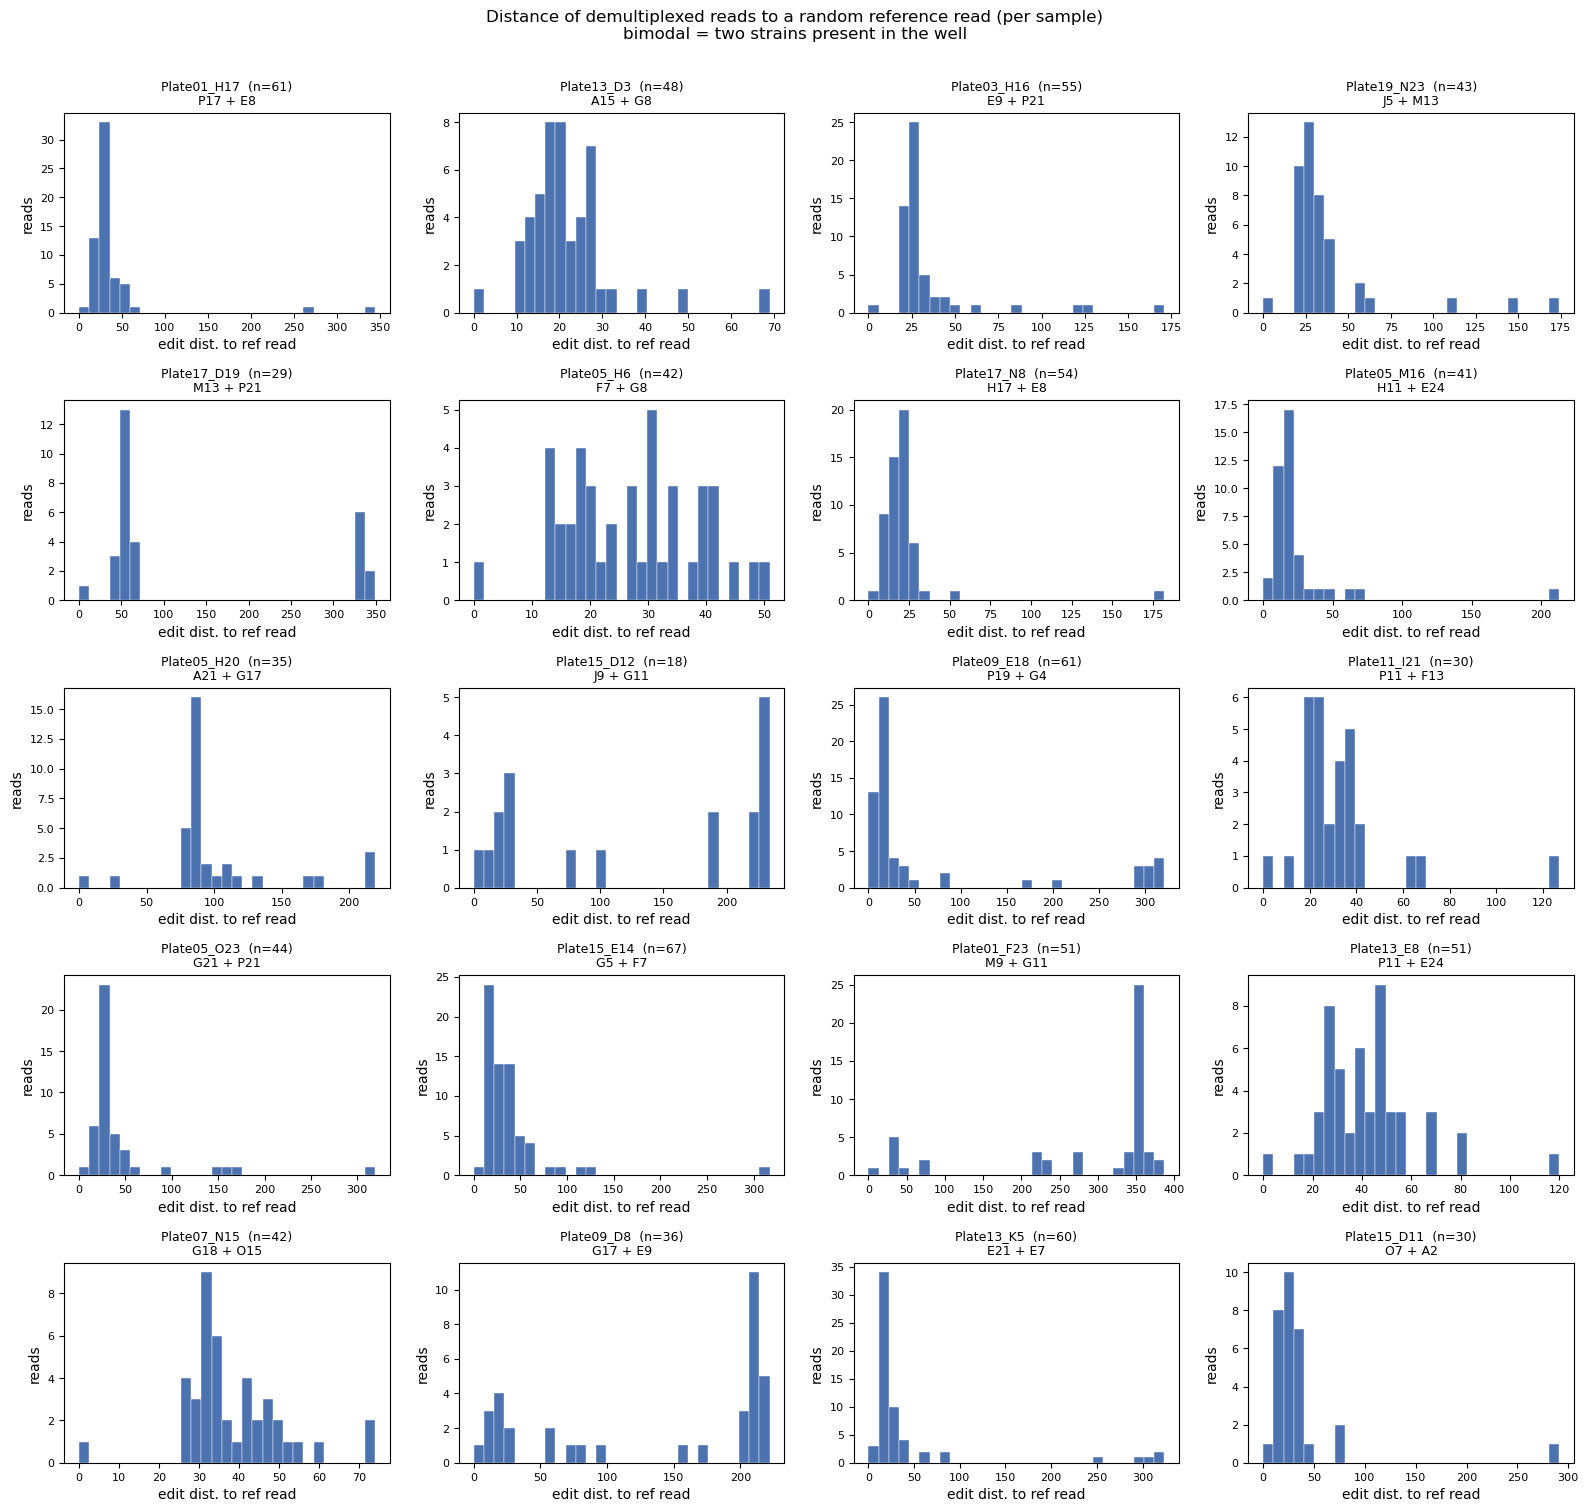

In [3]:
# ---- one random reference read per sample, histogram of distances ----------
ncols = 4
nrows = int(np.ceil(len(chosen) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, c in zip(axes, chosen):
    seqs = c["seqs"]
    ref_idx = rng.randrange(len(seqs))       # random reference read
    dists = distances_to_reference(seqs, ref_idx)

    ax.hist(dists, bins=np.linspace(0, dists.max() + 1e-6, 30),
            color="#4C72B0", edgecolor="white", linewidth=0.3)
    ax.set_title(f"{c['sample_id']}  (n={len(seqs)})\n{c['strain1']} + {c['strain2']}",
                 fontsize=9)
    ax.set_xlabel("edit dist. to ref read")
    ax.set_ylabel("reads")
    ax.tick_params(labelsize=8)

# hide any unused axes
for ax in axes[len(chosen):]:
    ax.axis("off")

fig.suptitle("Distance of demultiplexed reads to a random reference read (per sample)\n"
             "bimodal = two strains present in the well", fontsize=12, y=1.005)
fig.tight_layout()
plt.show()


---

## Estimating the number of strains per sample (all samples, complete pairwise distances)

The section above eyeballs one reference read per well. Here we do it properly for **every** sample with **more than 10 reads**:

1. **Complete pairwise edit distances** — for each sample, compute the normalized edit distance between *every pair* of reads (not just to one reference). This gives a much more thorough distance distribution.
2. **Same-vs-different threshold** — pooled across all samples, the pairwise distances are strongly bimodal: a low mode (same strain, differing only by ONT error) and a high mode (different strains). We pick the threshold at the empty valley between them.
3. **Cluster → count strains** — within each sample, reads closer than the threshold are grouped (single-linkage connected components). Each sufficiently large cluster is one strain, so the number of such clusters is the estimated number of strains in the well.

Each well was *designed* as a pair (2 strains), so most samples should resolve to 2; deviations (1 = one strain dropped out / dominated, 3+ = contamination) are the interesting cases.

In [4]:
# ===========================================================================
# Full analysis: estimate # strains per sample from COMPLETE pairwise dists
# ===========================================================================
import time
from math import ceil

MIN_STRAIN_READS = 3       # a cluster must have >= this many reads ...
MIN_STRAIN_FRAC  = 0.10    # ... and >= this fraction of the sample to count as a strain
DIST_THRESHOLD   = 0.08    # normalized edit dist below which two reads = same strain
                           #   (refined data-driven in the pooled-distribution cell below)


def all_pairwise_norm_dists(seqs):
    """Complete pairwise normalized edit distances, in condensed (i<j) order."""
    n = len(seqs)
    lens = [len(s) for s in seqs]
    d = np.empty(n * (n - 1) // 2, dtype=np.float32)
    k = 0
    for i in range(n):
        si, li = seqs[i], lens[i]
        for j in range(i + 1, n):
            ed = edlib.align(si, seqs[j], mode="NW", task="distance")["editDistance"]
            d[k] = ed / max(li, lens[j])
            k += 1
    return d


def _uf_find(parent, x):
    root = x
    while parent[root] != root:
        root = parent[root]
    while parent[x] != root:          # path compression
        parent[x], x = root, parent[x]
    return root


def cluster_reads(dvec, n, threshold):
    """Single-linkage connected components: reads within `threshold` = same strain.
    (The same/different modes are cleanly separated, so no chaining across the gap.)
    Returns cluster sizes, largest first."""
    parent = list(range(n))
    k = 0
    for i in range(n):
        for j in range(i + 1, n):
            if dvec[k] < threshold:
                ri, rj = _uf_find(parent, i), _uf_find(parent, j)
                if ri != rj:
                    parent[ri] = rj
            k += 1
    sizes = {}
    for x in range(n):
        r = _uf_find(parent, x)
        sizes[r] = sizes.get(r, 0) + 1
    return sorted(sizes.values(), reverse=True)


def estimate_n_strains(cluster_sizes, n, min_reads=MIN_STRAIN_READS, min_frac=MIN_STRAIN_FRAC):
    """# of clusters large enough to be a real strain (filters ONT chimeras / stray reads)."""
    cutoff = max(min_reads, ceil(min_frac * n))
    return sum(1 for s in cluster_sizes if s >= cutoff)

In [5]:
# ---- gather EVERY sample (pair or mono) with more than 10 reads ------------
def count_reads_fast(path):
    """Fast read count without full FASTQ parsing (4 lines per record)."""
    opener = gzip.open if str(path).endswith(".gz") else open
    with opener(path, "rb") as f:
        return sum(1 for _ in f) // 4

all_samples = []
for _, r in layout.iterrows():
    path = sample_fastq_path(r["dest_plate"], r["dest_well"])
    if path is None:
        continue
    n = count_reads_fast(path)
    if n > 10:
        all_samples.append({
            "sample_id": f"Plate{int(r['dest_plate']):02d}_{r['dest_well']}",
            "path": path,
            "well_type": r.get("well_type"),
            "strain1": r.get("strain1"),
            "strain2": r.get("strain2"),
            "n_reads": n,
        })

print(f"{len(all_samples)} samples have > 10 reads (out of {len(layout)} wells)")
print("well types:", pd.Series([c['well_type'] for c in all_samples]).value_counts().to_dict())

2779 samples have > 10 reads (out of 9120 wells)
well types: {'pair': 2745, 'mono': 34}


In [6]:
# ---- complete pairwise edit-distance distribution for every sample ---------
# Heavy step: several million edlib alignments. Expect ~1-3 min.
t0 = time.time()
dist_vectors = {}     # sample_id -> condensed normalized-distance vector (all read pairs)
total_pairs = 0
for idx, c in enumerate(all_samples):
    seqs = load_reads(c["path"], max_reads=100000)   # ALL reads (cap far above max)
    c["n_reads"] = len(seqs)
    dvec = all_pairwise_norm_dists(seqs)
    dist_vectors[c["sample_id"]] = dvec
    total_pairs += dvec.size
    if (idx + 1) % 250 == 0:
        print(f"  {idx + 1:4d}/{len(all_samples)} samples  "
              f"({total_pairs:,} pairs, {time.time() - t0:.0f}s)")

print(f"done: {len(all_samples)} samples, {total_pairs:,} pairwise comparisons, "
      f"{time.time() - t0:.0f}s")

   250/2779 samples  (312,899 pairs, 10s)


   500/2779 samples  (593,309 pairs, 19s)


   750/2779 samples  (852,586 pairs, 27s)


  1000/2779 samples  (1,093,812 pairs, 35s)


  1250/2779 samples  (1,335,436 pairs, 43s)


...

  2000/2779 samples  (2,022,390 pairs, 64s)


  2250/2779 samples  (2,267,920 pairs, 72s)


  2500/2779 samples  (2,537,272 pairs, 80s)


  2750/2779 samples  (2,760,313 pairs, 87s)


done: 2779 samples, 2,795,702 pairwise comparisons, 88s


data-driven same/different-strain threshold = 0.08 (normalized edit dist)


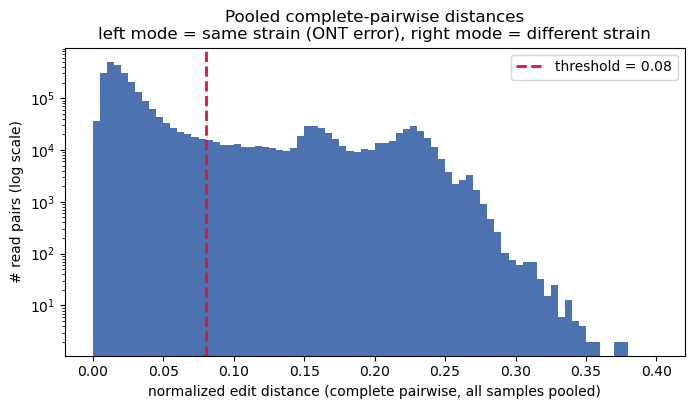

In [7]:
# ---- pooled pairwise-distance distribution -> same/different-strain split ---
pooled = np.concatenate([dist_vectors[c["sample_id"]] for c in all_samples])

# data-driven threshold: centre of the empty valley between the two modes
hist, edges = np.histogram(pooled, bins=np.linspace(0, 0.4, 81))
centers = 0.5 * (edges[:-1] + edges[1:])
band = (centers >= 0.04) & (centers <= 0.14)      # the gap between same/different modes
empty = band & (hist <= max(1, 0.001 * hist.max()))
DIST_THRESHOLD = round(float(np.median(centers[empty])), 3) if empty.any() else 0.08
print(f"data-driven same/different-strain threshold = {DIST_THRESHOLD} (normalized edit dist)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(pooled, bins=np.linspace(0, 0.4, 81), color="#4C72B0")
ax.axvline(DIST_THRESHOLD, color="crimson", ls="--", lw=2, label=f"threshold = {DIST_THRESHOLD}")
ax.set_xlabel("normalized edit distance (complete pairwise, all samples pooled)")
ax.set_ylabel("# read pairs (log scale)")
ax.set_yscale("log")
ax.set_title("Pooled complete-pairwise distances\nleft mode = same strain (ONT error), "
             "right mode = different strain")
ax.legend()
plt.show()

In [8]:
# ---- cluster each sample's reads -> estimate # strains represented ---------
rows = []
cluster_info = {}
for c in all_samples:
    sid = c["sample_id"]
    n = c["n_reads"]
    sizes = cluster_reads(dist_vectors[sid], n, DIST_THRESHOLD)
    est = estimate_n_strains(sizes, n)
    cluster_info[sid] = sizes
    rows.append({
        "sample_id": sid,
        "well_type": c["well_type"],
        "strain1": c["strain1"],
        "strain2": c["strain2"],
        "n_reads": n,
        "est_strains": est,
        "n_raw_clusters": len(sizes),
        "cluster_sizes": sizes,
        "top_frac": sizes[0] / n if sizes else 0.0,
    })

results = pd.DataFrame(rows)
print(f"estimated strain counts for {len(results)} samples")
results.head(10)

estimated strain counts for 2779 samples


,sample_id,well_type,strain1,strain2,n_reads,est_strains,n_raw_clusters,cluster_sizes,top_frac
0,Plate01_B2,pair,C20,G9,32,1,1,[32],1.000000
1,Plate01_B3,pair,O13,O9,59,1,2,"[58, 1]",0.983051
2,Plate01_B5,pair,C14,E12,68,1,4,"[64, 2, 1, 1]",0.941176
3,Plate01_B6,pair,G3,E20,62,1,2,"[61, 1]",0.983871
4,Plate01_B7,pair,O7,M19,74,1,4,"[70, 2, 1, 1]",0.945946
5,Plate01_B9,pair,F23,H19,25,1,1,[25],1.000000
6,Plate01_B10,pair,P19,H23,67,1,2,"[66, 1]",0.985075
7,Plate01_B11,pair,G3,C20,65,1,1,[65],1.000000
8,Plate01_B12,pair,H19,E2,87,1,2,"[86, 1]",0.988506
9,Plate01_B13,pair,G6,O11,67,1,2,"[65, 2]",0.970149


Samples analyzed (>10 reads): 2779
Threshold used: 0.08 normalized edit distance
A cluster counts as a strain if it has >= max(3, ceil(0.1*n_reads)) reads

Estimated # strains per sample:
  1 strain(s):  2163 samples  (77.8%)
  2 strain(s):   515 samples  (18.5%)
  3 strain(s):    92 samples  ( 3.3%)
  4 strain(s):     8 samples  ( 0.3%)
  5 strain(s):     1 samples  ( 0.0%)

By well type (rows = designed well type, cols = estimated # strains):
est_strains     1    2   3  4  5
well_type                       
mono           28    6   0  0  0
pair         2135  509  92  8  1

pair wells: 18.5% resolve to exactly 2 strains
mono wells: 82.4% resolve to exactly 1 strain


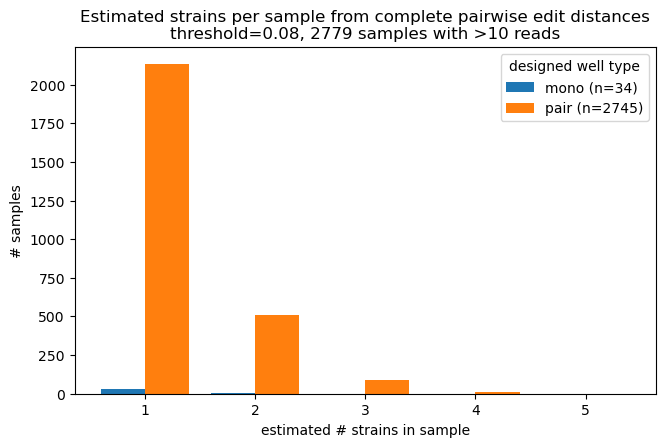

In [9]:
# ---- report: how many strains per sample -----------------------------------
print(f"Samples analyzed (>10 reads): {len(results)}")
print(f"Threshold used: {DIST_THRESHOLD} normalized edit distance")
print(f"A cluster counts as a strain if it has >= max({MIN_STRAIN_READS}, "
      f"ceil({MIN_STRAIN_FRAC}*n_reads)) reads\n")

print("Estimated # strains per sample:")
overall = results["est_strains"].value_counts().sort_index()
for k, v in overall.items():
    print(f"  {k} strain(s): {v:5d} samples  ({100 * v / len(results):4.1f}%)")

print("\nBy well type (rows = designed well type, cols = estimated # strains):")
print(pd.crosstab(results["well_type"], results["est_strains"]))

pair = results[results.well_type == "pair"]
if len(pair):
    print(f"\npair wells: {(pair.est_strains == 2).mean() * 100:.1f}% resolve to exactly 2 strains")
mono = results[results.well_type == "mono"]
if len(mono):
    print(f"mono wells: {(mono.est_strains == 1).mean() * 100:.1f}% resolve to exactly 1 strain")

fig, ax = plt.subplots(figsize=(7.5, 4.5))
xs = sorted(results.est_strains.unique())
for wt, sub in results.groupby("well_type"):
    vc = sub["est_strains"].value_counts()
    offset = 0.2 if wt == "pair" else -0.2
    ax.bar([x + offset for x in xs], [vc.get(x, 0) for x in xs],
           width=0.4, label=f"{wt} (n={len(sub)})")
ax.set_xlabel("estimated # strains in sample")
ax.set_ylabel("# samples")
ax.set_xticks(xs)
ax.set_title(f"Estimated strains per sample from complete pairwise edit distances\n"
             f"threshold={DIST_THRESHOLD}, {len(results)} samples with >10 reads")
ax.legend(title="designed well type")
plt.show()

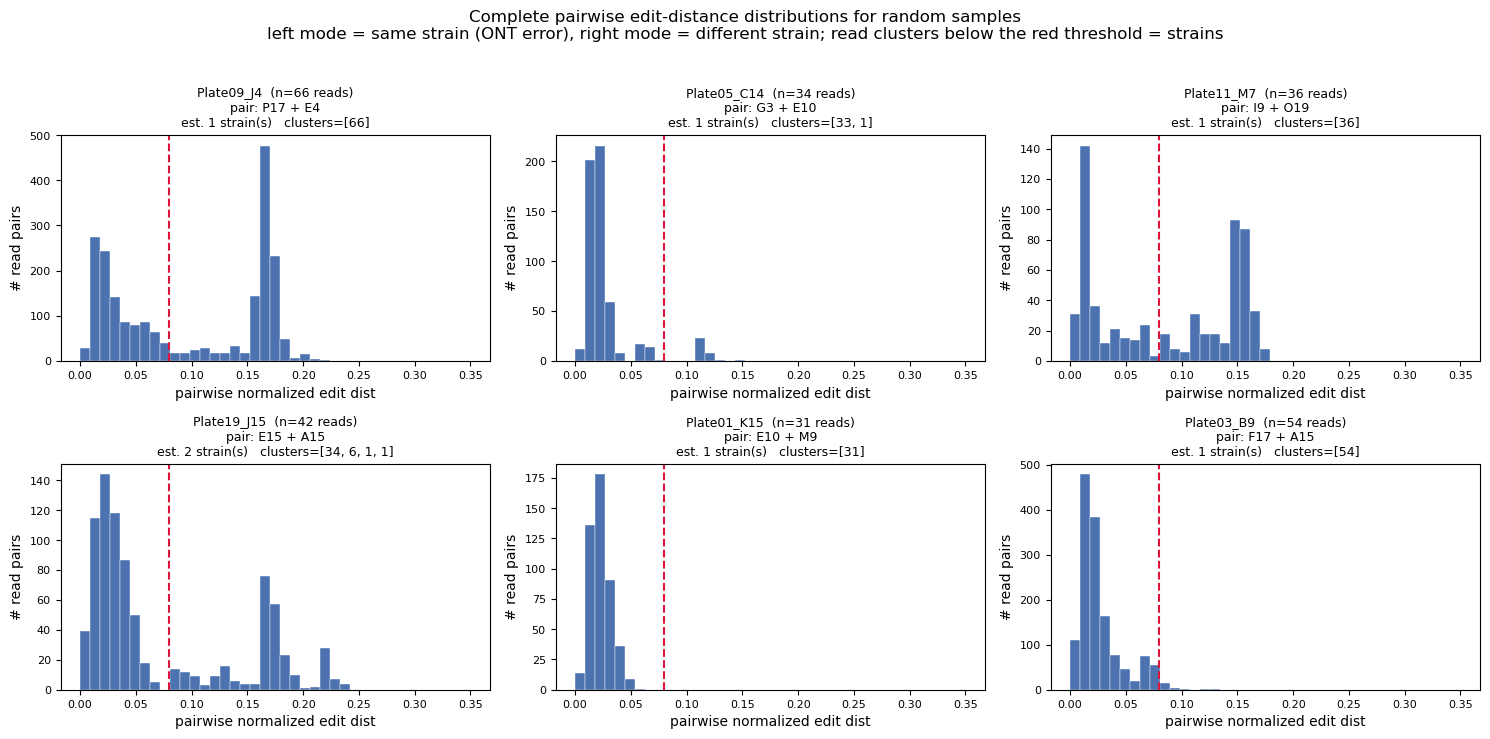

In [10]:
# ---- illustrate a few randomly chosen samples ------------------------------
show_rng = random.Random(SEED + 7)
picks = show_rng.sample(list(results.index), 6)

ncols = 3
nrows = int(np.ceil(len(picks) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.6 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, ridx in zip(axes, picks):
    row = results.loc[ridx]
    sid = row["sample_id"]
    dvec = dist_vectors[sid]
    ax.hist(dvec, bins=np.linspace(0, max(0.35, float(dvec.max()) + 1e-6), 40),
            color="#4C72B0", edgecolor="white", linewidth=0.3)
    ax.axvline(DIST_THRESHOLD, color="crimson", ls="--", lw=1.5)
    sizes = row["cluster_sizes"]
    ax.set_title(f"{sid}  (n={row['n_reads']} reads)\n"
                 f"{row['well_type']}: {row['strain1']} + {row['strain2']}\n"
                 f"est. {row['est_strains']} strain(s)   clusters={sizes[:5]}",
                 fontsize=9)
    ax.set_xlabel("pairwise normalized edit dist")
    ax.set_ylabel("# read pairs")
    ax.tick_params(labelsize=8)

for ax in axes[len(picks):]:
    ax.axis("off")

fig.suptitle("Complete pairwise edit-distance distributions for random samples\n"
             "left mode = same strain (ONT error), right mode = different strain; "
             "read clusters below the red threshold = strains",
             fontsize=12, y=1.02)
fig.tight_layout()
plt.show()